In [ ]:
# ===== 사용자 설정 =====
SUB   = "sub-01"
TASK  = "rsvp"
SPACE = "MNI152NLin2009cAsym"
FMRIPREP_DIR = f"output/pilot"
BIDS_DIR     = f"pilot"
OUTDIR = "./hrf_test_outputs"

# 비교할 HRF 모델 (필요 최소)
HRF_MODELS = ["spm", "glover"] 

# 관심 조건 (없으면 events.tsv의 trial_type 전체 사용)
INTEREST_CONDS = [f"color_{i}" for i in range(1, 9)] + ["blank"]

# ========================
import json
import os, glob
import numpy as np
import pandas as pd
import joblib
import nibabel as nib
import matplotlib.pyplot as plt

from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import make_first_level_design_matrix, FirstLevelModel
from nilearn.image import load_img, index_img
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.maskers import NiftiSpheresMasker, NiftiMasker
from nilearn import plotting
from nilearn.masking import apply_mask
from nilearn.glm.contrasts import expression_to_contrast_vector

os.makedirs(OUTDIR, exist_ok=True)


In [ ]:
# ROI 마스크 경로 설정 (예: V4.nii.gz)
# roi_mask_path = "output/pilot/sub-01/anat/sub-01_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
roi_mask_path = f"output/pilot/sub-01/anat/sub-01_acq-mprage_space-{SPACE}_res-2_desc-brain_mask.nii.gz" 

if os.path.exists(roi_mask_path):
    print("ROI mask found. Using:", roi_mask_path)
    common_mask_img = load_img(roi_mask_path)
else:
    print("ROI mask not found. Using automatic mask.")
    common_mask_img = None   # → FirstLevelModel이 자동 생성
    
masker = NiftiMasker(mask_img=roi_mask_path, standardize=False).fit()

ROI mask found. Using: output/pilot/sub-01/anat/sub-01_acq-mprage_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz


In [ ]:
# fMRIPrep의 preproc BOLD 6개 run까지 사용
fmri_imgs = [
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-1_space-{SPACE}-2_desc-preproc_bold.nii.gz", ## TODO : 변수 사용
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-2_space-{SPACE}-2_desc-preproc_bold.nii.gz"
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-3_space-{SPACE}-2_desc-preproc_bold.nii.gz"
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-4_space-{SPACE}-2_desc-preproc_bold.nii.gz"
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-5_space-{SPACE}-2_desc-preproc_bold.nii.gz"
    f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-rsvp_run-6_space-{SPACE}-2_desc-preproc_bold.nii.gz"
]

In [ ]:
def get_run_tag_from_basename(bname: str):
    # 예: sub-01_task-rsvp_run-3_space-..._desc-preproc_bold.nii.gz -> "run-3"
    parts = bname.split("_")
    for p in parts:
        if p.startswith("run-"):
            return p  # run-1, run-2, ...
    return None

def events_path_for_bold(bold_path: str):
    # fMRIPrep 파일명에서 run 태그만 찾아 BIDS events 경로 구성(re 없이)
    bname = os.path.basename(bold_path)
    run_tag = get_run_tag_from_basename(bname)
    if run_tag is None:
        return f"{BIDS_DIR}/{SUB}/func/{SUB}_task-{TASK}_events.tsv"
    else:
        return f"{BIDS_DIR}/{SUB}/func/{SUB}_task-{TASK}_{run_tag}_events.tsv" # ok

    
def confounds_path_for_bold(bold_path: str):
    # fMRIPrep 파일명에서 run 태그만 찾아 BIDS events 경로 구성(re 없이)
    bname = os.path.basename(bold_path)
    run_tag = get_run_tag_from_basename(bname)
    if run_tag is None:
        return f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-{TASK}_desc-confounds_timeseries.tsv"
    else:
        return f"{FMRIPREP_DIR}/{SUB}/func/{SUB}_task-{TASK}_{run_tag}_desc-confounds_timeseries.tsv"
    
    
def frame_times_from_img(img_nii):
    # 프레임 시간 계산
    n_scans = img_nii.shape[-1]
    TR = 1.5 #img_nii.header.get_zooms()[3]
    frame_times = np.arange(n_scans) * TR
    return frame_times, TR, n_scans

def exp_condition_from_events(ev_df):
    onset = ev_df["onset"].to_numpy(float)
    dur   = ev_df["duration"].to_numpy(float)
    amp   = np.ones(len(ev_df), dtype=float)
    exp_condition = np.vstack([onset, dur, amp])  # shape == (3, n_events)

    return exp_condition

# 디자인 매트릭스에서 색상별 '메인' 컬럼만 골라내기 (derivative 제외)
def _pick_main_columns(design_matrix, color_names):
    cols = list(design_matrix.columns)
    main_cols = []
    for cname in color_names:
        # 후보: trial_type[cname] 또는 cname (derivative 제외)
        cand = [c for c in cols if (cname in c and "derivative" not in c)]
        if len(cand) == 1:
            main_cols.append(cand[0])
            continue
        # trial_type[...] 우선
        cand_tt = [c for c in cand if "trial_type" in c]
        if len(cand_tt) == 1:
            main_cols.append(cand_tt[0])
        else:
            raise RuntimeError(f"메인 컬럼 식별 실패: {cname} -> 후보 {cand}")
    return main_cols

# [ADD] voxel×run별 z-score (마지막 축=색상 8개)
def _zscore_voxel_run_last_axis(beta_tensor):
    beta_z = beta_tensor.copy()
    V, R, C = beta_z.shape
    for v in range(V):
        for r in range(R):
            x = beta_z[v, r, :]
            mu = x.mean()
            sd = x.std(ddof=1)
            beta_z[v, r, :] = (x - mu) / (sd if sd > 0 else 1.0)
    return beta_z

In [ ]:
for bold_path in fmri_imgs:
    img = nib.load(bold_path)
    frame_times_scan, TR, n_scans = frame_times_from_img(img)

    # 파형 시각화를 위한 조밀한 시간축(0.05s)
    tmax = frame_times_scan[-1] + TR
    frame_times_fine = np.arange(0.0, tmax, 0.05)

    ev_path = events_path_for_bold(bold_path)
    if not os.path.exists(ev_path):
        raise FileNotFoundError(f"events.tsv 없음: {ev_path}")
    ev = pd.read_csv(ev_path, sep="\t")

    # 조건 목록 정하기
    all_conds = sorted(ev["trial_type"].unique().tolist())
    conds = [c for c in INTEREST_CONDS if c in all_conds] or all_conds

    base = os.path.basename(bold_path).replace("_desc-preproc_bold.nii.gz", "")
    print(f"[RUN] {base} | TR={TR:.3f}s, n_scans={n_scans}")
    print(f"  -> events: {ev_path}")
    print(f"  -> conditions: {conds}")

    # (1) HRF 파형 시각화(연속형)
    for model in HRF_MODELS:
        plt.figure(figsize=(9, 4))
        for cond in conds:
            ev_c = ev[ev["trial_type"] == cond]
            if ev_c.empty:
                continue
            # get information from events.tsv
            ec = exp_condition_from_events(ev_c)
            reg_fine, names = compute_regressor(ec, hrf_model=model, frame_times=frame_times_fine)
            plt.plot(frame_times_fine, reg_fine[:, 0], label=cond)  # 기본 HRF 성분만 표시
        plt.title(f"{base} | HRF: {model}")
        plt.xlabel("Time (s)"); plt.ylabel("Regressor (a.u.)")
        plt.legend(ncol=4, fontsize=8)
        out_png = f"{OUTDIR}/{base}_HRF-{model}_fine.png"
        plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.close()
        print(f"  saved: {out_png}")

    # (2) TR 시점의 Design-ready regressor CSV 저장
    for model in HRF_MODELS:
        cols, mats = [], []
        for cond in conds:
            ev_c = ev[ev["trial_type"] == cond]
            if ev_c.empty:
                continue
            ec = exp_condition_from_events(ev_c)
            reg_scan, names = compute_regressor(ec, hrf_model=model, frame_times=frame_times_scan)
            # 열 이름: cond + _ + (compute_regressor가 반환한 성분명)
            for j, nm in enumerate(names):
                cols.append(f"{cond}_{nm}")
            mats.append(reg_scan)
        if mats:
            R = np.column_stack(mats)
            dm = pd.DataFrame(R, columns=cols)
            dm.insert(0, "time_s", frame_times_scan)
            out_csv = f"{OUTDIR}/{base}_design_ready_HRF-{model}.csv"
            dm.to_csv(out_csv, index=False)
            print(f"  saved: {out_csv}")

print("\n완료: 각 run별 HRF 파형 PNG + TR시점 리그래서 CSV가 생성되었습니다.")
print("※ amplitude 미지정 시 1로 가정했습니다(공식 시그니처: [onset, duration, amplitude]).")


[RUN] sub-01_task-rsvp_run-1_space-MNI152NLin2009cAsym_res-2 | TR=1.500s, n_scans=288
  -> events: pilot/sub-01/func/sub-01_task-rsvp_run-1_events.tsv
  -> conditions: ['color_1', 'color_2', 'color_3', 'color_4', 'color_5', 'color_6', 'color_7', 'color_8', 'blank']
  saved: ./hrf_test_outputs/sub-01_task-rsvp_run-1_space-MNI152NLin2009cAsym_res-2_HRF-spm_fine.png
  saved: ./hrf_test_outputs/sub-01_task-rsvp_run-1_space-MNI152NLin2009cAsym_res-2_HRF-glover_fine.png
  saved: ./hrf_test_outputs/sub-01_task-rsvp_run-1_space-MNI152NLin2009cAsym_res-2_design_ready_HRF-spm.csv
  saved: ./hrf_test_outputs/sub-01_task-rsvp_run-1_space-MNI152NLin2009cAsym_res-2_design_ready_HRF-glover.csv
[RUN] sub-01_task-rsvp_run-2_space-MNI152NLin2009cAsym_res-2 | TR=1.500s, n_scans=275
  -> events: pilot/sub-01/func/sub-01_task-rsvp_run-2_events.tsv
  -> conditions: ['color_1', 'color_2', 'color_3', 'color_4', 'color_5', 'color_6', 'color_7', 'color_8', 'blank']
  saved: ./hrf_test_outputs/sub-01_task-rsvp_r

In [ ]:
# HRF/GLM 설정(공식 기본 흐름)
HRF_MODEL   = "glover + derivative"
DRIFT_MODEL = "cosine" # "polynomial" | "cosine" | None -> 보정
HIGH_PASS   = 0.01 # 노이즈 필터링 컷오프 (Hz)
NOISE_MODEL = "ar1" # 시계열 노이즈 모델

# fMRIPrep confounds 전략: "simple" | "compcor" | "ica_aroma"
CONFOUND_STRATEGY = "compcor"

In [ ]:
# ---------- 8.2.2: Design matrix (event-based + confounds) ----------

design_mats = []
trs = []  # run별 TR 저장(혼합 TR이면 per-run 처리 위해)
run_idx = 0

for bold_path in fmri_imgs:
    img = nib.load(bold_path)
    frame_times, TR, n_scans = frame_times_from_img(img); trs.append(TR)

    # get event informations
    ev_path = events_path_for_bold(bold_path)
    ev = pd.read_csv(ev_path, sep="\t")
    all_conds = sorted(ev["trial_type"].unique().tolist())
    use_conds = [c for c in INTEREST_CONDS if c in all_conds] or all_conds
    ev = ev[ev["trial_type"].isin(use_conds)].copy()

    conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)

    X = make_first_level_design_matrix(
        frame_times=frame_times,
        events=ev,
        hrf_model=HRF_MODEL,
        drift_model=DRIFT_MODEL,
        high_pass=HIGH_PASS,
        add_regs=conf_df.values,
        add_reg_names=list(conf_df.columns),
    )
    design_mats.append(X)
    
    out_csv = os.path.join(OUTDIR, f"{SUB}_{TASK}_run-{run_idx+1}_design_matrix.csv")
    X.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    
    from nilearn.plotting import plot_design_matrix

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_design_matrix(X, ax=ax)
    out_png = os.path.join(OUTDIR, f"{SUB}_{TASK}_run-{run_idx+1}_design_matrix.png")
    fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png)
    
    run_idx += 1

/tmp/ipykernel_632847/970525974.py:17: UserWarning: The following parameters are not needed for the selected strategy 'simple': ['strategy']; parameters accepted: ['motion', 'wm_csf', 'global_signal', 'demean']
  conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)
/tmp/ipykernel_632847/970525974.py:37: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(X, ax=ax)


Saved: ./hrf_test_outputs/sub-01_rsvp_run-1_design_matrix.csv
Saved: ./hrf_test_outputs/sub-01_rsvp_run-1_design_matrix.png
Saved: ./hrf_test_outputs/sub-01_rsvp_run-2_design_matrix.csv


/tmp/ipykernel_632847/970525974.py:17: UserWarning: The following parameters are not needed for the selected strategy 'simple': ['strategy']; parameters accepted: ['motion', 'wm_csf', 'global_signal', 'demean']
  conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)
/tmp/ipykernel_632847/970525974.py:37: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(X, ax=ax)


Saved: ./hrf_test_outputs/sub-01_rsvp_run-2_design_matrix.png
Saved: ./hrf_test_outputs/sub-01_rsvp_run-3_design_matrix.csv


/tmp/ipykernel_632847/970525974.py:17: UserWarning: The following parameters are not needed for the selected strategy 'simple': ['strategy']; parameters accepted: ['motion', 'wm_csf', 'global_signal', 'demean']
  conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)
/tmp/ipykernel_632847/970525974.py:37: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(X, ax=ax)


...

Saved: ./hrf_test_outputs/sub-01_rsvp_run-4_design_matrix.png
Saved: ./hrf_test_outputs/sub-01_rsvp_run-5_design_matrix.csv


/tmp/ipykernel_632847/970525974.py:17: UserWarning: The following parameters are not needed for the selected strategy 'simple': ['strategy']; parameters accepted: ['motion', 'wm_csf', 'global_signal', 'demean']
  conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)
/tmp/ipykernel_632847/970525974.py:37: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(X, ax=ax)


Saved: ./hrf_test_outputs/sub-01_rsvp_run-5_design_matrix.png
Saved: ./hrf_test_outputs/sub-01_rsvp_run-6_design_matrix.csv


/tmp/ipykernel_632847/970525974.py:17: UserWarning: The following parameters are not needed for the selected strategy 'simple': ['strategy']; parameters accepted: ['motion', 'wm_csf', 'global_signal', 'demean']
  conf_df, _ = load_confounds_strategy(bold_path, strategy=CONFOUND_STRATEGY)
/tmp/ipykernel_632847/970525974.py:37: DeprecationWarning: The parameter "ax" will be removed in 0.13.0 release of Nilearn. Please use the parameter "axes" instead.
  plot_design_matrix(X, ax=ax)


Saved: ./hrf_test_outputs/sub-01_rsvp_run-6_design_matrix.png


In [ ]:
# ---------- 8.2.3: Fit first-level model & compute contrasts ----------
# 주의: run마다 TR이 다르면(드묾) run별 모델을 따로 fit하세요. (여기선 동일 TR 가정)

TR0 = trs[0]; assert all(abs(t-TR0) < 1e-6 for t in trs), "Mixed TR detected—fit per-run."
first_level = FirstLevelModel(
    t_r=TR0, hrf_model=HRF_MODEL,
    drift_model=DRIFT_MODEL, high_pass=HIGH_PASS,
    noise_model=NOISE_MODEL, minimize_memory=False
).fit(fmri_imgs, design_matrices=design_mats)

/tmp/ipykernel_630956/2100965213.py:4: UserWarning: If design matrices are supplied, [hrf_model, t_r] will be ignored.
  first_level = FirstLevelModel(
/tmp/ipykernel_630956/2100965213.py:4: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  first_level = FirstLevelModel(


In [ ]:
# 대비 정의: (1) 각 color_i vs blank (2) 모든 color 평균 vs blank
contrast_maps = {}
for i in range(1, 9):
    name = f"color_{i} - blank"
    contrast_maps[name] = first_level.compute_contrast(name, output_type="z_score")

avg_colors = " + ".join([f"color_{i}" for i in range(1, 9)])
avg_vs_blank = f"({avg_colors})/8 - blank"
contrast_maps["avg_colors - blank"] = first_level.compute_contrast(avg_vs_blank, output_type="z_score")

# 저장 및 간단 표시
for cname, zmap in contrast_maps.items():
    safe = cname.replace(" ", "").replace("+", "plus").replace("/", "div").replace("-", "minus")
    out_nii = os.path.join(OUTDIR, f"{SUB}_{TASK}_{safe}_zmap.nii.gz")
    zmap.to_filename(out_nii)
    print("Saved:", out_nii)
    # PNG 썸네일(선택)
    png = out_nii.replace(".nii.gz", ".png")
    display = plotting.plot_stat_map(zmap, threshold=3.1, display_mode="z", cut_coords=7,
                                     title=cname, colorbar=True)
    display.savefig(png); display.close(); print("Saved:", png)

In [19]:
joblib.dump(first_level, os.path.join(OUTDIR, f"{SUB}_{TASK}_firstlevel.joblib"))
print("Saved model:", os.path.join(OUTDIR, f"{SUB}_{TASK}_firstlevel.joblib"))

Saved model: ./hrf_test_outputs/sub-01_rsvp_firstlevel.joblib


In [ ]:
# ---------- 8.2.4: Predicted time series & residuals (ROI 예시) ----------
# 첫 번째 run의 관측/예측/잔차 시계열을 ROI에서 비교해 저장
# 각 ROI가 설명을 잘 했는지 평가하는 용도
# TODO: ROI 정의 후 활용

first_level = joblib.load(os.path.join(OUTDIR, f"{SUB}_{TASK}_firstlevel.joblib"))

for index in range(0, 6):
    observed = masker.fit_transform(fmri_imgs[index])            # (time, 1)
    predicted = masker.transform(first_level.predicted[index])   # (time, 1)
    residuals = masker.transform(first_level.residuals[index])   # (time, 1)

    obs_pred_res = pd.DataFrame({
        "observed":  observed.ravel(),
        "predicted": predicted.ravel(),
        "residuals": residuals.ravel(),
    })
    csv_path = os.path.join(OUTDIR, f"{SUB}_{TASK}_run{index + 1}_observed_predicted_residuals.csv")
    obs_pred_res.to_csv(csv_path, index=False); print("Saved:", csv_path)

Saved: ./hrf_test_outputs/sub-01_rsvp_run1_observed_predicted_residuals.csv
Saved: ./hrf_test_outputs/sub-01_rsvp_run2_observed_predicted_residuals.csv
Saved: ./hrf_test_outputs/sub-01_rsvp_run3_observed_predicted_residuals.csv


KeyboardInterrupt: 

In [ ]:
metrics = []
for index in range(0, 6):
    csv_path = os.path.join(OUTDIR, f"{SUB}_{TASK}_run{index + 1}_observed_predicted_residuals.csv")
    df = pd.read_csv(csv_path)
    observed = df["observed"].to_numpy()
    predicted = df["predicted"].to_numpy()
    residuals = df["residuals"].to_numpy()

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((observed - observed.mean())**2)
    r = np.corrcoef(observed, predicted)[0, 1]
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean(residuals**2))

    metrics.append({
        "run": index + 1,
        "corr_obs_pred": r,
        "R2": r2,
        "residual_RMSE": rmse,
    })

metrics_df = pd.DataFrame(metrics)
metrics_path = os.path.join(OUTDIR, f"{SUB}_{TASK}_observed_predicted_residual_metrics.csv")
metrics_df.to_csv(metrics_path, index=False)
print("Saved metrics:", metrics_path)
display(metrics_df)

In [2]:
# contrast_maps 다시 불러오기(첫 세팅 실행 후 실행)
contrast_maps = {}

for fname in os.listdir(OUTDIR):
    if fname.endswith("_zmap.nii.gz"):
        cname = fname.split(f"{SUB}_{TASK}_")[1].replace("_zmap.nii.gz", "")
        img = nib.load(os.path.join(OUTDIR, fname))
        contrast_maps[cname] = img
        print("Loaded:", cname, img.shape)

Loaded: avg_colorsminusblank (97, 115, 97)
Loaded: color_1minusblank (97, 115, 97)
Loaded: color_7minusblank (97, 115, 97)
Loaded: color_5minusblank (97, 115, 97)
Loaded: color_8minusblank (97, 115, 97)
Loaded: color_2minusblank (97, 115, 97)
Loaded: color_6minusblank (97, 115, 97)
Loaded: color_4minusblank (97, 115, 97)
Loaded: color_3minusblank (97, 115, 97)


/tmp/ipykernel_208137/1511459232.py:14: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(mesh, tex, hemi=hemi, view="lateral",


Saved: ./hrf_test_outputs/sub-01_rsvp_avgColorsVsBlank_left_surf.png
Saved: ./hrf_test_outputs/sub-01_rsvp_avgColorsVsBlank_right_surf.png


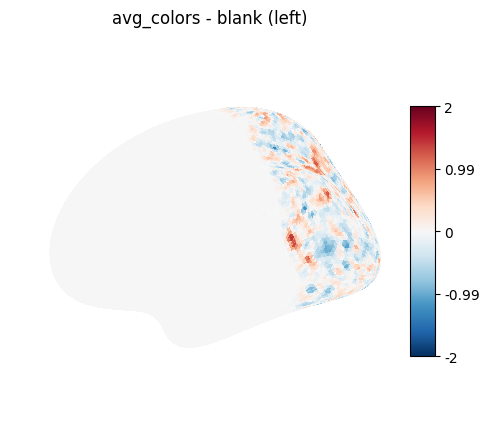

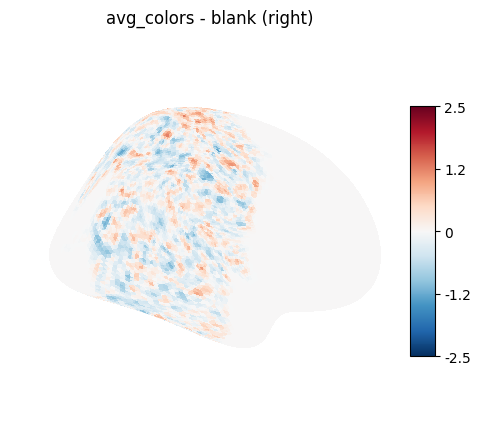

In [ ]:
# # ---------- (선택) 8.2.5: Surface-based analysis ----------
# # z-map을 표면으로 투영해 보려면 fsaverage 메쉬가 필요합니다.
# # 간단히 nilearn 내장 fsaverage5 메쉬를 쓰는 예:
# try:
#     from nilearn import surface, datasets
#     fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage5")
#     zmap = contrast_maps["avg_colorsminusblank"]
#     # 좌/우 반구로 투영
#     tex_l = surface.vol_to_surf(zmap, fsavg.pial_left, radius=3.0)
#     tex_r = surface.vol_to_surf(zmap, fsavg.pial_right, radius=3.0)
#     # 플롯 저장
#     for hemi, mesh, tex in [("left", fsavg.infl_left, tex_l),
#                             ("right", fsavg.infl_right, tex_r)]:
#         fig = plotting.plot_surf_stat_map(mesh, tex, hemi=hemi, view="lateral",
#                                           title=f"avg_colors - blank ({hemi})",
#                                           colorbar=True, bg_map=fsavg.sulc_left if hemi=="left" else fsavg.sulc_right)
#         out_png = os.path.join(OUTDIR, f"{SUB}_{TASK}_avgColorsVsBlank_{hemi}_surf.png")
#         fig.savefig(out_png)
#         print("Saved:", out_png)
# except Exception as e:
#     print("[Surface step skipped]", e)

/tmp/ipykernel_208137/2021778840.py:16: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(mesh, tex, hemi=hemi, view="lateral",


Saved: ./hrf_test_outputs/sub-01_rsvp_avgColor_7_VsBlank_left_surf.png
Saved: ./hrf_test_outputs/sub-01_rsvp_avgColor_7_VsBlank_right_surf.png


/tmp/ipykernel_208137/2021778840.py:16: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_stat_map(mesh, tex, hemi=hemi, view="lateral",


Saved: ./hrf_test_outputs/sub-01_rsvp_avgColor_8_VsBlank_left_surf.png
Saved: ./hrf_test_outputs/sub-01_rsvp_avgColor_8_VsBlank_right_surf.png


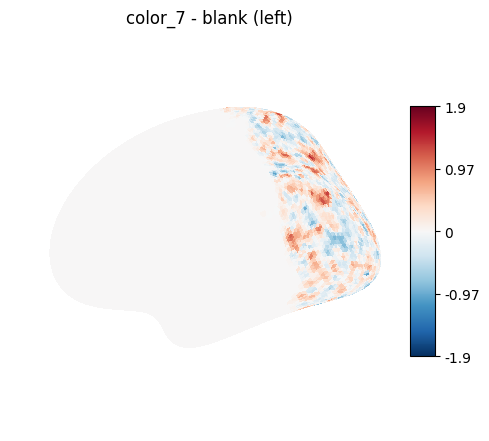

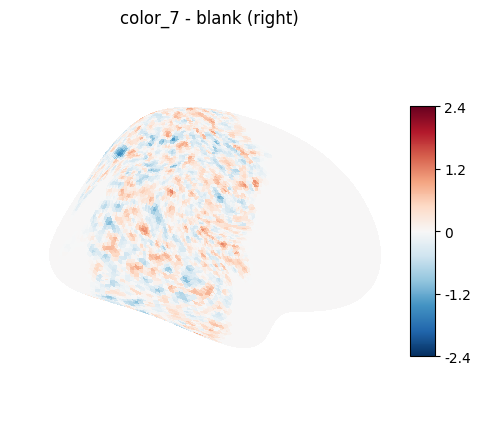

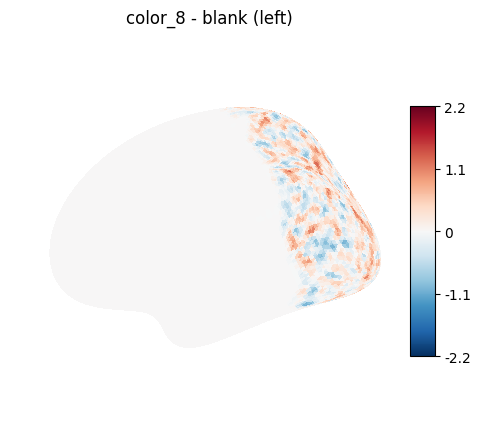

In [ ]:
# # ---------- (선택) 8.2.5: Surface-based analysis ----------
# # z-map을 표면으로 투영해 보려면 fsaverage 메쉬가 필요합니다.
# # 간단히 nilearn 내장 fsaverage5 메쉬를 쓰는 예:
# try:
#     from nilearn import surface, datasets
#     fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage5")
    
#     for index in range(7, 9):
#         zmap = contrast_maps[f"color_{index}minusblank"]
#         # 좌/우 반구로 투영
#         tex_l = surface.vol_to_surf(zmap, fsavg.pial_left, radius=3.0)
#         tex_r = surface.vol_to_surf(zmap, fsavg.pial_right, radius=3.0)
#         # 플롯 저장
#         for hemi, mesh, tex in [("left", fsavg.infl_left, tex_l),
#                                 ("right", fsavg.infl_right, tex_r)]:
#             fig = plotting.plot_surf_stat_map(mesh, tex, hemi=hemi, view="lateral",
#                                               title=f"color_{index} - blank ({hemi})",
#                                               colorbar=True, bg_map=fsavg.sulc_left if hemi=="left" else fsavg.sulc_right)
#             out_png = os.path.join(OUTDIR, f"{SUB}_{TASK}_avgColor_{index}_VsBlank_{hemi}_surf.png")
#             fig.savefig(out_png); 
#             print("Saved:", out_png)
# except Exception as e:
#     print("[Surface step skipped]", e)

In [ ]:
## 품질 확인
# ==== 9.x: Per-run voxel × color amplitudes (effect-size betas) ====

# 수정 최소화: run별로 따로 FirstLevelModel을 fit하고 각 color_i의 effect-size(β)를 추출
# 결과: run 마다 (n_voxels × 8colors) 행렬 저장 + voxel-wise z-score(각 run 단위)


In [15]:
RUN_FEATURES_DIR = OUTDIR + "/run_features/"

os.makedirs(RUN_FEATURES_DIR, exist_ok=True)

In [ ]:
def fit_one_run_and_get_betas(bold_path, mask_img=common_mask_img):
    # events 로드
    ev_path = events_path_for_bold(bold_path)
    ev = pd.read_csv(ev_path, sep="\t")
    all_conds = sorted(ev["trial_type"].unique().tolist())
    conds = [c for c in INTEREST_CONDS if c in all_conds] or all_conds 
    
    # run에 필요한 모든 color regressor가 최소 1개 이벤트라도 존재하는지 확인
    missing = [c for c in INTEREST_CONDS if c not in conds]
    if missing:
        print(f"[WARN] {bold_path} missing conditions: {missing} → skip this run for classification/reconstruction.")
        return None  # 호출부에서 제외
    
    ev = ev[ev["trial_type"].isin(conds)].copy()

    # TR/frame_times
    img = nib.load(bold_path)
    frame_times, TR, n_scans = frame_times_from_img(img)

    # run단위 모델 적합
    glm = FirstLevelModel(
        t_r=TR, hrf_model=HRF_MODEL,
        drift_model=DRIFT_MODEL, high_pass=HIGH_PASS,
        noise_model=NOISE_MODEL, minimize_memory=False
    ).fit(bold_path, events=ev)

    
    # 각 색상(regressor) 이름 수집(파생항 포함 가능)    
    # effect-size 산출 시에는 기본 regressor 이름으로 contrast 지정 가능
    color_regressors = [c for c in glm.design_matrices_[0].columns if any(c.startswith(cc) for cc in conds)]
    # color_i의 "기본" 성분만 쓰고 싶다면 아래처럼 필터링(원하면 유지/수정)
    base_regs = []
    for cc in conds:
        # 파생항 없이 'cc' 단독 혹은 'cc'로 시작하며 'deriv' 등 포함 안 하는 열 우선
        base = [r for r in color_regressors if r == cc or (r.startswith(cc) and ("deriv" not in r and "post" not in r))]
        base_regs.append(base[0] if base else cc)

    # 각 color의 effect-size 맵 → mask로 벡터화 → 열로 쌓기
    masker = NiftiMasker(mask_img=mask_img, standardize=False).fit()
    X_list, colnames = [], []
    for cc in base_regs:
        beta_img = glm.compute_contrast(cc, output_type="effect_size")
        X_list.append(masker.transform(beta_img))  # shape (1, n_vox)
        colnames.append(cc)
    # (n_colors, n_vox) → (n_vox, n_colors)
    X = np.vstack(X_list)        # (n_colors, n_vox)
    X = X.T                      # (n_vox, n_colors)

    # voxel-wise z-score(각 run 단위): 논문 절차
    Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

    return Xz, np.array(colnames)

In [ ]:
run_mats, run_labels = [], None
valid_run_indices = []

# 각 run별로 fit & beta 추출
for bold_path in fmri_imgs:
    out = fit_one_run_and_get_betas(bold_path, mask_img=common_mask_img)
    if out is None:
        continue  # 이 run은 스킵
    Xz, cols = out
    run_mats.append(Xz)               # (n_vox_common, n_colors)
    valid_run_indices.append(bold_path)
    if run_labels is None:
        run_labels = cols

print(f"[OK] Using {len(run_mats)} runs with a common voxel set. Each run matrix shape: {run_mats[0].shape}")
if len(run_mats) < 2:
    raise RuntimeError("Not enough valid runs after masking/condition check.")

/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm = FirstLevelModel(
/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm = FirstLevelModel(
/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm = FirstLevelModel(
/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm = FirstLevelModel(
/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably been centered. Scaling might not work as expected.
  glm = FirstLevelModel(
/tmp/ipykernel_664912/1438341740.py:21: UserWarning: Mean values of 0 observed. The data have probably be

[OK] Using 6 runs with a common voxel set.


In [45]:
# === Keep only color_* conditions, drop 'blank' (or any non-color) ===
keep_cols = [j for j, name in enumerate(run_labels.tolist()) if str(name).startswith("color_")]
if len(keep_cols) < len(run_labels):
    print("[INFO] Dropping non-color conditions:",
          [run_labels[j] for j in range(len(run_labels)) if j not in keep_cols])
    # run_mats: list of (n_vox, n_conditions) → slice columns
    run_mats = [X[:, keep_cols] for X in run_mats]
    run_labels = run_labels[keep_cols]   # e.g., ["color_1", ..., "color_8"]


In [ ]:
# 상위 |z| voxel 선택 (예: 5000개) — run_mats: list of (n_vox_common, n_colors)
## TODO: Strict에서는 z-score만 맞추기

k = 5000
absz = np.mean([np.abs(X) for X in run_mats], axis=0)  # (n_vox, n_colors) 평균 |z| 

score = absz.max(axis=1)                               # voxel 스코어
topk_idx = np.argsort(score)[::-1][:k]
run_mats_k = [X[topk_idx, :] for X in run_mats]

print(f"[OK] Selected top {k} voxels based on mean |z| scores.")

In [ ]:
# ==== 9.y: 8-way classification (leave-one-run-out, diag-linear) ====
# 공분산을 대각으로 가정한 간단한 최대우도 분류기(논문 가정과 합치)

def diag_linear_predict(train_X, train_y, test_X):
    # train_X: (N, D), train_y: (N,), test_X: (M, D)
    classes = np.unique(train_y)
    means = np.stack([train_X[train_y==c].mean(axis=0) for c in classes])  # (C, D)
    vars_  = np.stack([train_X[train_y==c].var(axis=0) + 1e-8 for c in classes])   # (C, D)
    # log-likelihood under diagonal Gaussians
    # ll_c(x) = -0.5 * [ sum log(2πσ^2) + sum (x-μ)^2/σ^2 ]
    ll = []
    for k in range(len(classes)):
        ll_k = -0.5*(np.log(2*np.pi*vars_[k]).sum() + ((test_X - means[k])**2/vars_[k]).sum(axis=1))
        ll.append(ll_k)
    ll = np.stack(ll, axis=1)  # (M, C)
    preds = classes[ll.argmax(axis=1)]
    return preds

# 샘플 구성: 한 run에서 n_vox×n_colors → n_colors개의 샘플(각 샘플은 n_vox차원 벡터)
# (컬러는 레이블, 피처는 voxel축)으로 맞춰서 쌓음
samples_per_run = []
for Xz in run_mats_k:
    # Xz: (n_vox, n_colors) → (n_colors, n_vox)
    samples_per_run.append(Xz.T)

# LOAO(run) 평가: 각 run을 테스트로, 나머지를 훈련으로
colors = run_labels
all_preds, all_true = [], []
for test_idx in range(len(samples_per_run)):
    X_train = np.vstack([samples_per_run[i] for i in range(len(samples_per_run)) if i!=test_idx])
    y_train = np.tile(colors, len(samples_per_run)-1)
    X_test  = samples_per_run[test_idx]
    y_test  = colors

    y_pred = diag_linear_predict(X_train, y_train, X_test)
    acc = (y_pred == y_test).mean()
    print(f"[Classification] Test {test_idx+1}: acc={acc:.3f}")
    all_preds.append(y_pred); all_true.append(y_test)

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true)
color_names = np.array(colors)
per_color_acc = (all_preds == all_true).mean(axis=0)
rank_order = np.argsort(per_color_acc)[::-1]
print('\n[Classification] Per-color accuracy:')
for idx in rank_order:
    print(f'  {color_names[idx]}: {per_color_acc[idx]:.3f}')

## 색상별 성능 파악
best_idx = rank_order[0]
worst_idx = rank_order[-1]
print('\n[Classification] Best color: {} ({:.3f})'.format(color_names[best_idx], per_color_acc[best_idx]))
print('[Classification] Worst color: {} ({:.3f})'.format(color_names[worst_idx], per_color_acc[worst_idx]))
error_counts = np.zeros((len(color_names), len(color_names)), dtype=int)
for fold_true, fold_pred in zip(all_true, all_preds):
    for t, p in zip(fold_true, fold_pred):
        if t != p:
            idx_t = np.where(color_names == t)[0][0]
            idx_p = np.where(color_names == p)[0][0]
            error_counts[idx_t, idx_p] += 1

worst_true = color_names[worst_idx]
mis_target = error_counts[worst_idx]
if mis_target.sum() > 0:
    most_confused_idx = np.argmax(mis_target)
    print('[Classification] Worst color misclassified mostly as {} ({} errors)'.format(color_names[most_confused_idx], mis_target[most_confused_idx]))
else:
    print('[Classification] Worst color had no misclassifications (unexpected).')

best_true = color_names[best_idx]
mis_best = error_counts[best_idx]
if mis_best.sum() > 0:
    major_idx = np.argmax(mis_best)
    print('[Classification] Best color still misclassified as {} ({} errors)'.format(color_names[major_idx], mis_best[major_idx]))
else:
    print('[Classification] Best color had zero misclassifications.')


[Classification] Test 1: acc=0.625
[Classification] Test 2: acc=0.375
[Classification] Test 3: acc=0.500
[Classification] Test 4: acc=0.750
[Classification] Test 5: acc=0.625
[Classification] Test 6: acc=0.250


In [68]:
def corr_classifier(train_X, train_y, test_X):
    classes = np.unique(train_y)
    protos = np.stack([train_X[train_y==c].mean(axis=0) for c in classes])  # (C, D)
    # 코사인 유사도
    A = test_X / (np.linalg.norm(test_X, axis=1, keepdims=True)+1e-8)
    P = protos / (np.linalg.norm(protos, axis=1, keepdims=True)+1e-8)
    sims = A @ P.T  # (M, C)
    return classes[sims.argmax(axis=1)]

In [ ]:
def perm_test_accuracy(predict_fn, X_train, y_train, X_test, y_test, n_perm=1000):
    rng = np.random.default_rng(42)
    # 진짜 정확도
    acc_true = (predict_fn(X_train, y_train, X_test) == y_test).mean()
    # 귀무분포
    acc_null = []
    for _ in range(n_perm):
        y_shuf = rng.permutation(y_train)
        acc_null.append((predict_fn(X_train, y_shuf, X_test) == y_test).mean())
    acc_null = np.array(acc_null)
    # p-value와 임계치
    p_val = (np.sum(acc_null >= acc_true) + 1) / (n_perm + 1)
    thr975 = np.quantile(acc_null, 0.975)
    return acc_true, p_val, thr975, acc_null


In [ ]:
for test_idx in range(len(samples_per_run)):
    X_train = np.vstack([samples_per_run[i] for i in range(len(samples_per_run)) if i!=test_idx])
    y_train = np.tile(run_labels, len(samples_per_run)-1)
    X_test  = samples_per_run[test_idx]
    y_test  = run_labels

    # 대각-MLC
    acc, p, thr, nulls = perm_test_accuracy(diag_linear_predict, X_train, y_train, X_test, y_test)
    print(f"[Diag-MLC] Run {test_idx+1}: acc={acc:.3f}, p={p:.3f}, thr={thr:.3f}")


[Diag-MLC] Run 1: acc=0.750, p=0.001, thr=0.375
[CorrClass] Run 1: acc=0.375, p=0.062, thr=0.375
[Diag-MLC] Run 2: acc=0.625, p=0.001, thr=0.375
[CorrClass] Run 2: acc=0.250, p=0.261, thr=0.375
[Diag-MLC] Run 3: acc=0.750, p=0.001, thr=0.375
[CorrClass] Run 3: acc=0.250, p=0.236, thr=0.375
[Diag-MLC] Run 4: acc=0.625, p=0.001, thr=0.375
[CorrClass] Run 4: acc=0.250, p=0.266, thr=0.375
[Diag-MLC] Run 5: acc=0.750, p=0.001, thr=0.375
[CorrClass] Run 5: acc=0.500, p=0.017, thr=0.375
[Diag-MLC] Run 6: acc=0.500, p=0.008, thr=0.375
[CorrClass] Run 6: acc=0.250, p=0.270, thr=0.375


In [ ]:
# ==== 9.z: Forward model & reconstruction ====
# 6개의 half-wave rectified & squared sinusoid 기반 채널 정의(균등 6분할)

def channel_basis(num_channels=6, num_hues=360):
    # STUDY: 변환 과정 확인
    # 각 hue(0..359)에 대해 k개 채널의 출력(정규화 X, 그대로 사용해도 됨)
    hs = np.deg2rad(np.arange(num_hues))
    centers = np.deg2rad(np.linspace(0, 360, num_channels, endpoint=False))
    C = []
    for c in centers:
        t = np.cos(hs - c)  # sinusoid
        t = np.clip(t, 0, None)  # half-wave rectify
        t = t**2              # square
        C.append(t)
    C = np.array(C)  # (k, num_hues)
    return C

def forward_model_fit_predict(train_B, train_labels, test_B, hue_table):
    # train_B: (n_train, m_vox) 각 샘플은 특정 hue(=color label)
    # train_labels: (n_train,) 예: ["color_1", ...]
    # test_B: (n_test, m_vox)
    
    # 1) 학습 레이블을 8개 정점 hue로 매핑(균등 8분할 가정)
    color_to_hue = {f"color_{i+1}": i*(360//8) for i in range(8)}
    C1 = hue_table[:, [color_to_hue[c] for c in train_labels]]   # (k, n_train)
    B1 = train_B.T                                              # (m_vox, n_train)
    # 2) 가중치 추정: Ŵ = B1 C1^T (C1 C1^T)^-1
    W = (B1 @ C1.T) @ np.linalg.pinv(C1 @ C1.T)                 # (m_vox, k)
    # 3) 테스트 채널 출력 추정: Ĉ2 = (W^T W)^-1 W^T B2
    B2 = test_B.T                                               # (m_vox, n_test)
    C_hat = np.linalg.pinv(W.T @ W) @ (W.T @ B2)               # (k, n_test)
    # 4) 0..359 hue lookup과 상관계수 비교 → argmax
    #    (정규화 없이도 상관관계로 충분)
    #    hue_table: (k, 360)
    #    corr(Ĉ, C(h)) 최대인 h 선택
    #    상관 구현 간단화: 코사인 유사도 사용
    C_hat_n = C_hat / (np.linalg.norm(C_hat, axis=0, keepdims=True) + 1e-8)
    H_n     = hue_table / (np.linalg.norm(hue_table, axis=0, keepdims=True) + 1e-8)
    sims = C_hat_n.T @ H_n    # (n_test, 360)
    hues_pred = sims.argmax(axis=1)  # 0..359

    ## 출력 차원 -> (n_test,) : 각 샘플별 예측된 hue (0..359)
    return hues_pred 


In [ ]:
# 학습/평가(LOAO run)
hue_table = channel_basis(num_channels=6, num_hues=360)  # (k, 360)
print(hue_table)

for test_idx in range(len(samples_per_run)):
    X_train = np.vstack([samples_per_run[i] for i in range(len(samples_per_run)) if i!=test_idx])
    y_train = np.tile(colors, len(samples_per_run)-1)
    X_test  = samples_per_run[test_idx]
    y_test  = colors
    hues_pred = forward_model_fit_predict(X_train, y_train, X_test, hue_table)
    print(f"[ForwardModel-Recon] Test {test_idx+1} hues:", hues_pred)

In [37]:
# ================================
# Forward Model: Color Reconstruction (no ROI)
# - Uses PsychoPy RGB -> true hue(deg) as ground-truth
# - Leave-one-run-out evaluation, with permutation test
# - Ridge (lambda) for stability
# ================================

# 0) PsychoPy color definition (given)
COLOR_RGB = {
    'color_1': [-0.84,  0.20,  0.08],  # reddish
    'color_2': [-0.96, -0.24,  0.64],  # orange
    'color_3': [-0.98, -0.80,  0.96],  # yellow
    'color_4': [ 0.60, -0.56,  0.52],  # greenish
    'color_5': [ 1.00, -0.48, -0.56],  # cyan
    'color_6': [ 0.90,  0.24, -0.90],  # blue
    'color_7': [-0.24,  0.20, -0.72],  # violet
    'color_8': [-0.90, -0.20, -0.70],  # pinkish
    'blank':    [0.5, 0.5, 0.5],       # neutral gray
}

# --- Lab hue angle (deg) from your conversion ---
LABEL2HUE_DEG = {
    'color_1': float(178.5695366901941),
    'color_2': float(310.7676279123204),
    'color_3': float(316.10116190386),
    'color_4': float(333.8636890033205),
    'color_5': float(54.5026811654645),
    'color_6': float(68.44990693644588),
    'color_7': float(130.78364209927355),
    'color_8': float(153.7216350869142),
    # 'blank'는 평가에서 제외
}



In [ ]:

# 1) Utility: RGB(-1..1) -> HSV hue(deg)
def _rgb_to_hsv_deg(rgb01):
    r, g, b = rgb01
    mx, mn = max(rgb01), min(rgb01)
    diff = mx - mn
    if diff == 0:
        h = 0.0
    elif mx == r:
        h = (60 * ((g - b) / diff) + 360) % 360
    elif mx == g:
        h = (60 * ((b - r) / diff) + 120) % 360
    else:
        h = (60 * ((r - g) / diff) + 240) % 360
    s = 0.0 if mx == 0 else diff / mx
    v = mx
    return h, s, v

def build_label_to_hue_deg(color_rgb_dict):
# label2hue: dict of label -> hue(deg)
    label2hue = {}
    for label, rgb in color_rgb_dict.items():
        # map [-1,1] -> [0,1] safely
        rgb01 = [np.clip((x + 1) / 2, 0.0, 1.0) for x in rgb]
        hue_deg, _, _ = _rgb_to_hsv_deg(rgb01)
        label2hue[label] = hue_deg
    return label2hue

LABEL2HUE_DEG = build_label_to_hue_deg(COLOR_RGB)

def color_true_deg_from_labels(labels, label2hue=LABEL2HUE_DEG):
# label -> true hue (deg), nan for non-color labels
    arr = []
    for lbl in labels:
        val = label2hue.get(str(lbl), np.nan)  # blank 등은 nan
        arr.append(val)
    return np.array(arr, dtype=float)

# 2) Channel basis: 6 half-wave rectified, squared sinusoids (k x 360)
def channel_basis(num_channels=6, num_hues=360):
    hs = np.deg2rad(np.arange(num_hues))
    centers = np.deg2rad(np.linspace(0, 360, num_channels, endpoint=False))
    C = []
    for c in centers:
        t = np.cos(hs - c)
        t = np.clip(t, 0, None)
        t = t**2
        C.append(t)
    return np.array(C)  # (k, 360)

# 3) Forward model fit/predict with ridge
## STUDY: hue lookup -> filter weights W -> test channel outputs -> hue prediction 
def forward_model_fit_predict(train_B, train_labels, test_B, hue_table, lam=1e-2):
    """
    train_B: (n_train, m_vox)   train_labels: (n_train,)
    test_B : (n_test, m_vox)    hue_table: (k, 360)
    returns: predicted hues (deg in 0..359) for each test sample
    """
    # keep color_* only
    keep = np.array([str(lbl).startswith("color_") for lbl in train_labels])
    train_B = train_B[keep]
    train_labels = np.array(train_labels)[keep]
    if train_B.shape[0] == 0:
        raise ValueError("No valid color_* labels in training set.")

    # map labels -> true hues (closest column in hue_table; but we can use direct columns if desired)
    # here we simply use the nearest degree column in hue_table
    train_hues_deg = color_true_deg_from_labels(train_labels)
    # convert deg to int indices [0..359]
    train_hue_idx = np.mod(np.round(train_hues_deg).astype(int), 360)

    C1 = hue_table[:, train_hue_idx]   # (k(channels), n_train)
    B1 = train_B.T                     # (m_vox, n_train)
    k = C1.shape[0]
    # W = B1 C1^T (C1 C1^T + lam I)^-1
    W = (B1 @ C1.T) @ np.linalg.pinv(C1 @ C1.T + lam*np.eye(k))

    B2 = test_B.T                      # (m_vox, n_test)
    # C_hat = (W^T W + lam I)^-1 W^T B2
    C_hat = np.linalg.pinv(W.T @ W + lam*np.eye(k)) @ (W.T @ B2)  # (k, n_test)

    # cosine similarity to all 360 hue prototypes
    C_hat_n = C_hat / (np.linalg.norm(C_hat, axis=0, keepdims=True) + 1e-8)
    H_n = hue_table / (np.linalg.norm(hue_table, axis=0, keepdims=True) + 1e-8)
    sims = C_hat_n.T @ H_n  # (n_test, 360)
    hues_pred = sims.argmax(axis=1)  # int deg indices
    return hues_pred.astype(float)

# 4) Circular difference (deg) and permutation test on hit-rate
def circular_diff_deg(a, b):
    d = np.abs(a - b) % 360.0
    return np.minimum(d, 360.0 - d)

def forward_perm_test_hit_rate(train_B, train_labels, test_B, test_labels,
                               hue_table, lam=1e-2, n_perm=1000, tol_deg=22.5, rng_seed=7):
    # filter test to color_* only (drop blanks)
    true_deg = color_true_deg_from_labels(test_labels)  # may contain nan
    keep = ~np.isnan(true_deg)

    # divide test set
    test_B = test_B[keep]
    test_labels = np.array(test_labels)[keep]
    true_deg = true_deg[keep]
    if test_B.shape[0] == 0:
        raise ValueError("No valid test samples after filtering non-color labels.")

    # true hit-rate
    hues_pred = forward_model_fit_predict(train_B, train_labels, test_B, hue_table, lam=lam)
    hit_true = (circular_diff_deg(hues_pred, true_deg) <= tol_deg).mean()

    # permutation null
    rng = np.random.default_rng(rng_seed)
    hits = []
    for _ in range(n_perm):
        shuf = rng.permutation(train_labels)
        hues_perm = forward_model_fit_predict(train_B, shuf, test_B, hue_table, lam=lam)
        hits.append((circular_diff_deg(hues_perm, true_deg) <= tol_deg).mean())
    hits = np.array(hits)
    p = (np.sum(hits >= hit_true) + 1) / (n_perm + 1)
    thr975 = np.quantile(hits, 0.975)
    return hit_true, p, thr975, hits, hues_pred, true_deg

# 5) Build samples_per_run (n_colors, n_vox) from run_mats (n_vox, n_conditions)
#    and keep only color_* columns
def _filter_color_columns(run_mats_k, run_labels):
    keep_cols = [j for j, name in enumerate(run_labels.tolist()) if str(name).startswith("color_")]
    if len(keep_cols) < len(run_labels):
        print("[INFO] Dropping non-color conditions:",
              [run_labels[j] for j in range(len(run_labels)) if j not in keep_cols])
        run_mats = [X[:, keep_cols] for X in run_mats_k]
        run_labels = run_labels[keep_cols]
    return run_mats, run_labels

run_mats_k, run_labels = _filter_color_columns(run_mats_k, run_labels)
samples_per_run = [X.T for X in run_mats_k]  # list of (n_colors, n_vox)

# 6) Run LOAO reconstruction with permutation test (no ROI)
hue_table = channel_basis(num_channels=6, num_hues=360)
LAM = 1e-2      # ridge strength
TOL = 22.5      # hit tolerance in degrees (half of 45°)
N_PERM = 1000   # permutations

all_hits, all_ps, all_thrs = [], [], []
all_pred_deg, all_true_deg = [], []

for test_idx in range(len(samples_per_run)):
    X_train = np.vstack([samples_per_run[i] for i in range(len(samples_per_run)) if i!=test_idx])
    y_train = np.tile(run_labels, len(samples_per_run)-1)
    X_test  = samples_per_run[test_idx]
    y_test  = run_labels

    hit, p, thr, hits_null, hues_pred_deg, true_deg = forward_perm_test_hit_rate(
        X_train, y_train, X_test, y_test,
        hue_table, lam=LAM, n_perm=N_PERM, tol_deg=TOL, rng_seed=7
    )
    print(f"[Forward-Recon] Run {test_idx+1}: hit={hit:.3f}, p={p:.3f}, thr={thr:.3f} "
          f"(tol={TOL}°, lam={LAM}, n_perm={N_PERM})")

    all_hits.append(hit); all_ps.append(p); all_thrs.append(thr)
    all_pred_deg.append(hues_pred_deg); all_true_deg.append(true_deg)

print(f"[Forward-Recon] MEAN hit={np.mean(all_hits):.3f}, "
      f"MEAN p={np.mean(all_ps):.3f}, "
      f"MEAN thr={np.mean(all_thrs):.3f}")


NameError: name 'run_mats_k' is not defined

In [ ]:
# ================================
# One-figure polar plot: all runs, clustered around each stimulus hue
# ================================


COMBO_DIR = os.path.join(OUTDIR, "forward_viz")
os.makedirs(COMBO_DIR, exist_ok=True)
COMBO_PATH = os.path.join(COMBO_DIR, "all_runs_polar_clusters.png")

# 1) 시각화용 색상: PsychoPy RGB(-1..1) -> matplotlib RGB(0..1)
def _rgb_to_mpl(rgb_pm1):
    # [-1,1] to [0,1]
    return tuple(float(np.clip((x + 1)/2, 0, 1)) for x in rgb_pm1)

LABEL2COLOR = {lbl: _rgb_to_mpl(COLOR_RGB[lbl]) for lbl in COLOR_RGB if lbl.startswith("color_")}

# 2) 라벨별로 모든 run의 예측 각도를 모읍니다.
def gather_predictions_by_label(all_pred_deg, run_labels):
    """
    all_pred_deg: list of arrays, each shape (n_colors,)
    run_labels: array/list of labels for columns, e.g., ["color_1",...,"color_8"]
    return: dict[label] -> list of predicted degrees across runs
    """
    lab2preds = {lab: [] for lab in run_labels if str(lab).startswith("color_")}
    for pred_deg in all_pred_deg:
        for j, lab in enumerate(run_labels):
            if str(lab).startswith("color_"):
                lab2preds[str(lab)].append(float(pred_deg[j]))
    return lab2preds

lab2preds = gather_predictions_by_label(all_pred_deg, run_labels)

# 3) 원형 평균(벡터) 계산 보조 함수(선택)
def circular_mean_deg(angles_deg):
    if len(angles_deg) == 0:
        return np.nan, 0.0
    ang = np.deg2rad(np.asarray(angles_deg))
    C = np.cos(ang).mean()
    S = np.sin(ang).mean()
    mean_ang = (np.rad2deg(np.arctan2(S, C)) + 360) % 360
    R = np.hypot(C, S)  # 0~1, 클수록 집중도↑
    return mean_ang, R

# 4) 플롯
plt.figure(figsize=(7,7))
ax = plt.subplot(111, projection='polar')
ax.set_title("All runs: True hues and prediction clusters", pad=18)
ax.set_rticks([])                      # 반지름 눈금 숨김
ax.set_theta_zero_location("E")        # 0°를 오른쪽
ax.set_theta_direction(-1)             # 시계방향이 +각
ax.grid(alpha=0.25)

rng = np.random.default_rng(3)
r_center = 1.0
r_pred_base = 0.92

# 각 색상에 대해 중심점 + 모든 예측 점 + (선택) 원형 평균 벡터
for lab in [l for l in run_labels if str(l).startswith("color_")]:
    true_deg = LABEL2HUE_DEG[lab]
    theta_true = np.deg2rad(true_deg)

    # 중심점(자극색으로 칠함)
    ax.scatter([theta_true], [r_center], s=110, color=LABEL2COLOR[lab], edgecolor='k', linewidths=0.8, zorder=4)

    # 예측 점들
    preds = lab2preds[lab]
    if len(preds):
        thetas = np.deg2rad(np.array(preds))
        # 반지름을 살짝 jitter해서 겹침 감소 (의미는 각도에만 있음)
        r_jit = r_pred_base + rng.uniform(-0.05, 0.05, size=len(thetas))
        ax.scatter(thetas, r_jit, s=28, color=LABEL2COLOR[lab], alpha=0.65, zorder=3)

        # (선택) 원형 평균 벡터(짧은 화살표)
        mu_deg, R = circular_mean_deg(preds)
        if not np.isnan(mu_deg):
            mu = np.deg2rad(mu_deg)
            # 벡터 길이를 R에 비례해 짧게
            r0, r1 = 0.70, 0.70 + 0.20*R
            ax.plot([mu, mu], [r0, r1], color=LABEL2COLOR[lab], linewidth=2.0, alpha=0.9, zorder=2)

# 간단 범례(마커 설명)
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k', label='True hue (stimulus)', markersize=10),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', alpha=0.65, label='Predictions (all runs)', markersize=6),
    Line2D([0],[0], color='gray', lw=2, label='Circular mean vector (per color)')
]
ax.legend(handles=legend_elems, loc='upper right', bbox_to_anchor=(1.25, 1.2))

plt.tight_layout()
plt.savefig(COMBO_PATH, dpi=150, bbox_inches='tight')
plt.close()

print(f"[Saved] {COMBO_PATH}")

[Saved] ./hrf_test_outputs/forward_viz/all_runs_polar_clusters.png
